# 🚢 Titanic Dataset — End-to-End Exploratory Data Analysis
**Project 1 | SyntecxHub Data Science Series**

**Dataset Source:** [Kaggle Titanic Competition](https://www.kaggle.com/competitions/titanic/data)

---
### 📋 Project Objectives
1. Load the Titanic dataset, inspect missingness and data types.
2. Analyze survival rates by **Sex**, **Passenger Class**, and **Age buckets**.
3. Visualize findings with bar charts, violin plots, and heatmaps.
4. Generate a short insight report with key findings.

---

## 📦 Step 1 — Install & Import Libraries

In [1]:
# Install missing libraries (Colab usually has these, but just in case)
!pip install pandas matplotlib seaborn missingno -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

print('Libraries imported successfully!')

Libraries imported successfully!


## 📂 Step 2 — Load Dataset

> **How to get the data:**
> - Option A: Download from [Kaggle Titanic](https://www.kaggle.com/competitions/titanic/data) and upload `train.csv` to Colab.
> - Option B: Use the Kaggle API (cell below).

In [8]:
#Upload manually ─────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # Upload train.csv
df = pd.read_csv('train.csv')

print(f'Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

Saving gender_submission.csv to gender_submission.csv
Saving test.csv to test.csv
Saving train.csv to train.csv
Dataset loaded: 891 rows × 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 🔍 Step 3 — Initial Inspection (Dtypes & Missingness)

In [9]:
print('=' * 50)
print('DATASET INFO')
print('=' * 50)
df.info()

print('\n' + '=' * 50)
print('DESCRIPTIVE STATISTICS')
print('=' * 50)
df.describe(include='all').T

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

DESCRIPTIVE STATISTICS


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292



📊 Missing Value Report:
          Missing Count  Missing %
Cabin               687      77.10
Age                 177      19.87
Embarked              2       0.22


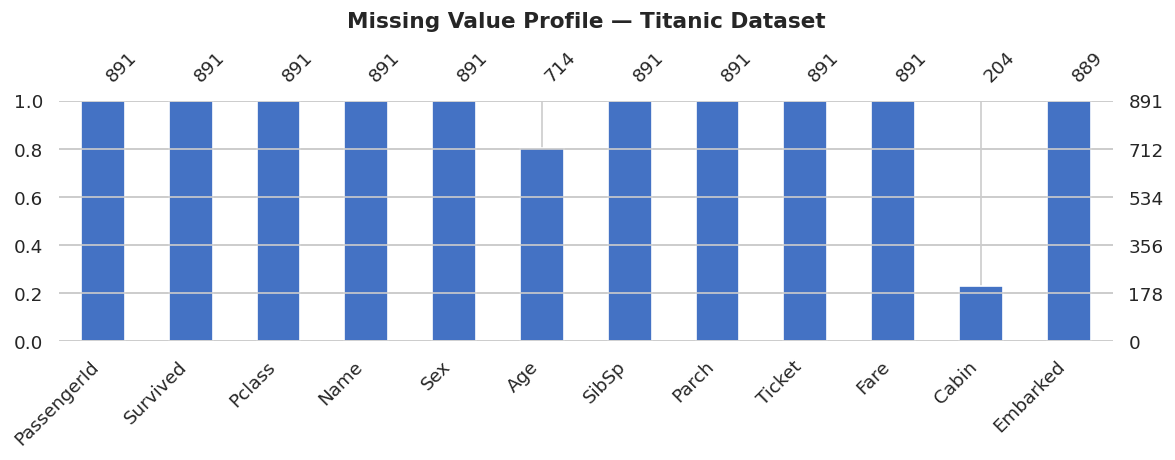


⚠️  Cabin (77%) and Age (20%) have significant missingness — handle before modelling.


In [10]:
# Missing value summary
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
miss_df = miss_df[miss_df['Missing Count'] > 0]

print('\n📊 Missing Value Report:')
print(miss_df.to_string())

# Visual: Missing value matrix
fig, ax = plt.subplots(figsize=(10, 4))
msno.bar(df, ax=ax, color='#4472C4', fontsize=11)
ax.set_title('Missing Value Profile — Titanic Dataset', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()
print('\n⚠️  Cabin (77%) and Age (20%) have significant missingness — handle before modelling.')

## 🧹 Step 4 — Data Cleaning & Feature Engineering

In [11]:
df_clean = df.copy()

# 1. Fill missing Age with median by Pclass & Sex
df_clean['Age'] = df_clean.groupby(['Pclass', 'Sex'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Fill Embarked with mode
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)

# 3. Create AgeBucket feature
df_clean['AgeBucket'] = pd.cut(
    df_clean['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child (0-12)', 'Teen (13-18)', 'Adult (19-35)', 'Middle (36-60)', 'Senior (60+)']
)

# 4. Create FareGroup
df_clean['FareGroup'] = pd.qcut(
    df_clean['Fare'], q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

# 5. Family size
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1
df_clean['IsAlone'] = (df_clean['FamilySize'] == 1).astype(int)

print('✅ Feature engineering complete!')
print(f"Age nulls remaining: {df_clean['Age'].isnull().sum()}")
df_clean[['Age', 'AgeBucket', 'FamilySize', 'IsAlone', 'FareGroup']].head(8)

✅ Feature engineering complete!
Age nulls remaining: 0


,Age,AgeBucket,FamilySize,IsAlone,FareGroup
0,22.0,Adult (19-35),2,0,Low
1,38.0,Middle (36-60),2,0,Very High
2,26.0,Adult (19-35),1,1,Medium
3,35.0,Adult (19-35),2,0,Very High
4,35.0,Adult (19-35),1,1,Medium
5,25.0,Adult (19-35),1,1,Medium
6,54.0,Middle (36-60),1,1,Very High
7,2.0,Child (0-12),5,0,High


## 📊 Step 5 — Overall Survival Rate

Total Passengers : 891
Survived         : 342 (38.4%)
Perished         : 549 (61.6%)


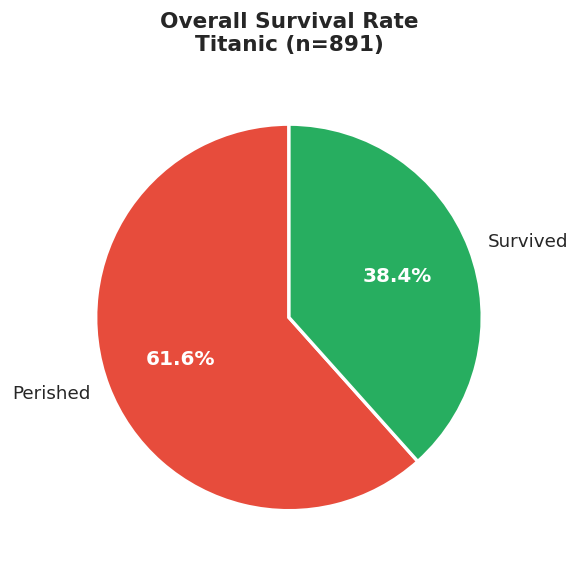

In [12]:
survived = df_clean['Survived'].sum()
total = len(df_clean)
rate = df_clean['Survived'].mean()

print(f'Total Passengers : {total}')
print(f'Survived         : {survived} ({rate:.1%})')
print(f'Perished         : {total - survived} ({1-rate:.1%})')

fig, ax = plt.subplots(figsize=(5, 5))
colors = ['#E74C3C', '#27AE60']
wedges, texts, autotexts = ax.pie(
    [total - survived, survived],
    labels=['Perished', 'Survived'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
    at.set_color('white')

ax.set_title('Overall Survival Rate\nTitanic (n=891)', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('survival_overall.png', bbox_inches='tight')
plt.show()

## 👥 Step 6 — Survival by Sex

   Sex  Survived  Total     Rate
female       233    314 0.742038
  male       109    577 0.188908


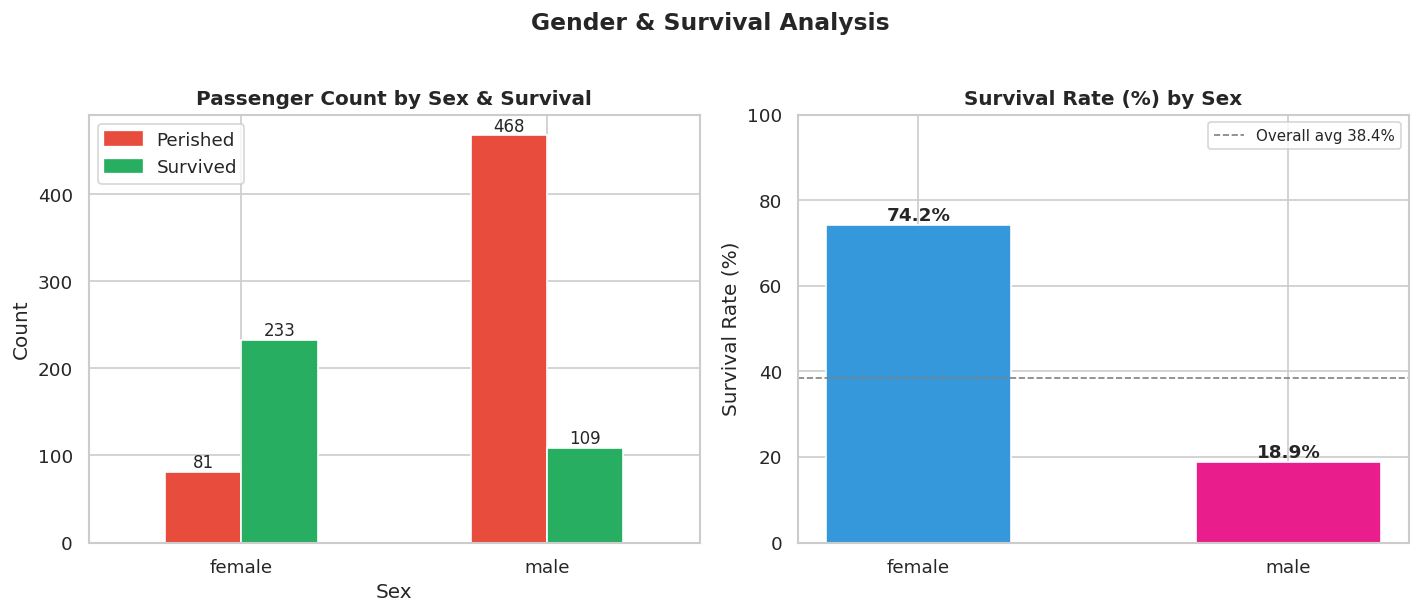


🔑 Key: Females survived at 74.2% vs Males at 18.9% — "Women & children first" policy confirmed.


In [13]:
sex_surv = df_clean.groupby('Sex')['Survived'].agg(['sum', 'count', 'mean']).reset_index()
sex_surv.columns = ['Sex', 'Survived', 'Total', 'Rate']
print(sex_surv.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Count
ax = axes[0]
surv_count = df_clean.groupby(['Sex', 'Survived']).size().unstack()
surv_count.plot(kind='bar', ax=ax, color=['#E74C3C', '#27AE60'],
                edgecolor='white', rot=0, legend=False)
ax.set_title('Passenger Count by Sex & Survival', fontsize=12, fontweight='bold')
ax.set_xlabel('Sex'); ax.set_ylabel('Count')
labels = [mpatches.Patch(color='#E74C3C', label='Perished'),
          mpatches.Patch(color='#27AE60', label='Survived')]
ax.legend(handles=labels)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

# Plot 2: Rate
ax = axes[1]
colors_sex = ['#3498DB', '#E91E8C']
bars = ax.bar(sex_surv['Sex'], sex_surv['Rate']*100, color=colors_sex,
              edgecolor='white', width=0.5)
ax.set_title('Survival Rate (%) by Sex', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)'); ax.set_ylim(0, 100)
ax.axhline(rate*100, color='gray', linestyle='--', linewidth=1, label=f'Overall avg {rate:.1%}')
ax.legend(fontsize=9)
for bar, r in zip(bars, sex_surv['Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{r:.1%}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Gender & Survival Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('survival_by_sex.png', bbox_inches='tight')
plt.show()
print('\n🔑 Key: Females survived at 74.2% vs Males at 18.9% — "Women & children first" policy confirmed.')

## 🎫 Step 7 — Survival by Passenger Class

PclassLabel  Survived  Total     Rate
  1st Class       136    216 0.629630
  2nd Class        87    184 0.472826
  3rd Class       119    491 0.242363


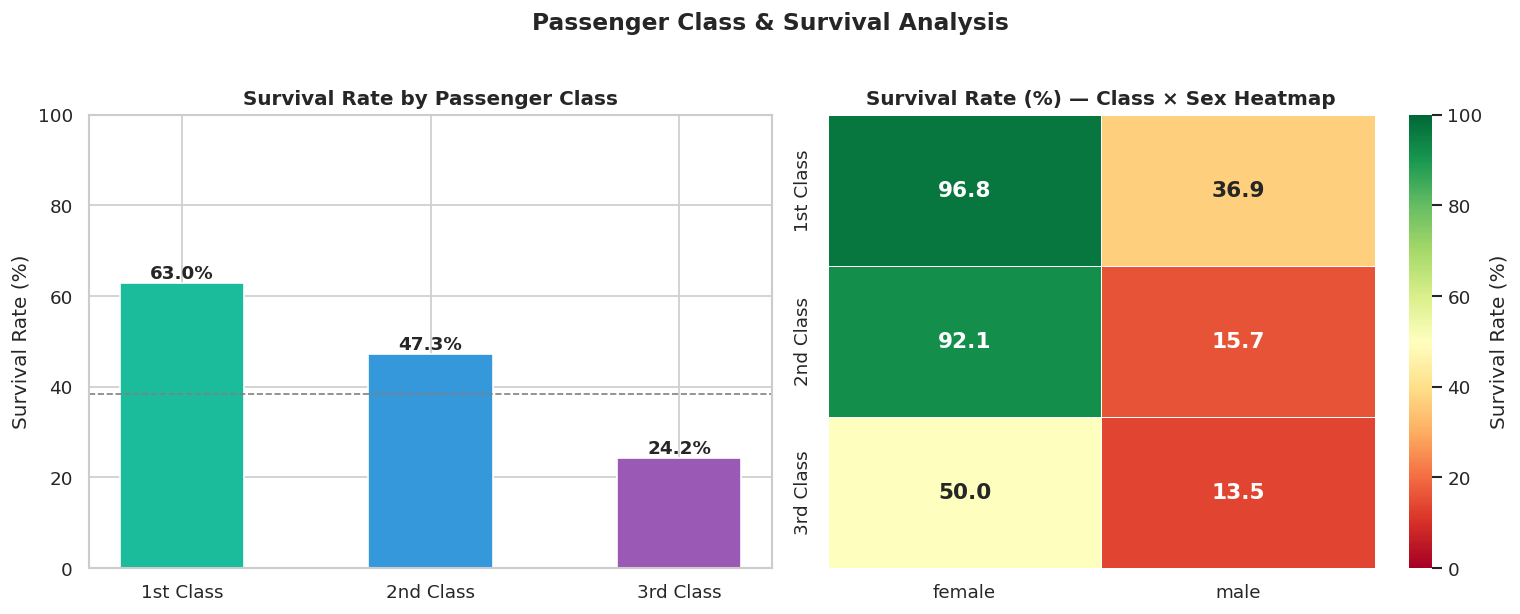


🔑 1st class females: 96.8% survival | 3rd class males: 13.5% survival


In [14]:
pclass_surv = df_clean.groupby('Pclass')['Survived'].agg(['mean','sum','count']).reset_index()
pclass_surv.columns = ['Pclass', 'Rate', 'Survived', 'Total']
pclass_surv['PclassLabel'] = pclass_surv['Pclass'].map({1:'1st Class', 2:'2nd Class', 3:'3rd Class'})
print(pclass_surv[['PclassLabel','Survived','Total','Rate']].to_string(index=False))

# Grouped bar by Class + Sex
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Survival rate by class
ax = axes[0]
class_colors = ['#1ABC9C', '#3498DB', '#9B59B6']
bars = ax.bar(pclass_surv['PclassLabel'], pclass_surv['Rate']*100,
              color=class_colors, edgecolor='white', width=0.5)
ax.set_title('Survival Rate by Passenger Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 100)
ax.axhline(rate*100, color='gray', linestyle='--', linewidth=1)
for bar, r in zip(bars, pclass_surv['Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{r:.1%}', ha='center', fontweight='bold', fontsize=11)

# Right: Heatmap Class x Sex
ax = axes[1]
pivot = df_clean.pivot_table('Survived', index='Pclass', columns='Sex', aggfunc='mean') * 100
pivot.index = ['1st Class', '2nd Class', '3rd Class']
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Survival Rate (%)'},
            vmin=0, vmax=100, annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Survival Rate (%) — Class × Sex Heatmap', fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('')

plt.suptitle('Passenger Class & Survival Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('survival_by_class.png', bbox_inches='tight')
plt.show()
print('\n🔑 1st class females: 96.8% survival | 3rd class males: 13.5% survival')

## 🎂 Step 8 — Survival by Age (Violin + Bar)

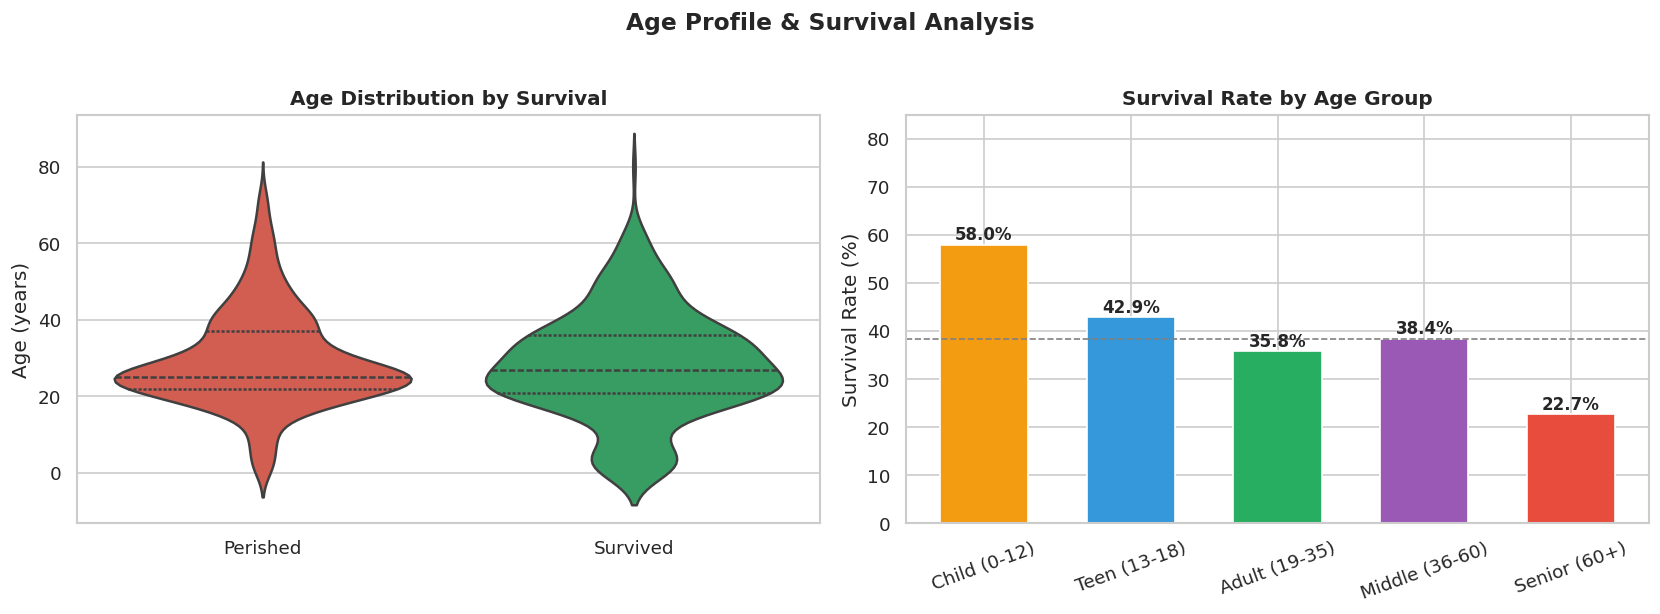


🔑 Children had the highest survival rate (58%), Seniors the lowest (22.7%)


In [15]:
age_surv = df_clean.groupby('AgeBucket')['Survived'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Violin plot
ax = axes[0]
sns.violinplot(data=df_clean, x='Survived', y='Age',
               palette=['#E74C3C', '#27AE60'],
               inner='quartile', ax=ax, linewidth=1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Perished', 'Survived'], fontsize=11)
ax.set_title('Age Distribution by Survival', fontsize=12, fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('Age (years)')

# Bar chart by age bucket
ax = axes[1]
bucket_colors = ['#F39C12', '#3498DB', '#27AE60', '#9B59B6', '#E74C3C']
bars = ax.bar(age_surv['AgeBucket'].astype(str), age_surv['Survived']*100,
              color=bucket_colors, edgecolor='white', width=0.6)
ax.set_title('Survival Rate by Age Group', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 85)
ax.tick_params(axis='x', rotation=20)
ax.axhline(rate*100, color='gray', linestyle='--', linewidth=1)
for bar, r in zip(bars, age_surv['Survived']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{r:.1%}', ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Age Profile & Survival Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('survival_by_age.png', bbox_inches='tight')
plt.show()
print('\n🔑 Children had the highest survival rate (58%), Seniors the lowest (22.7%)')

## 💰 Step 9 — Fare & Embarkation Analysis

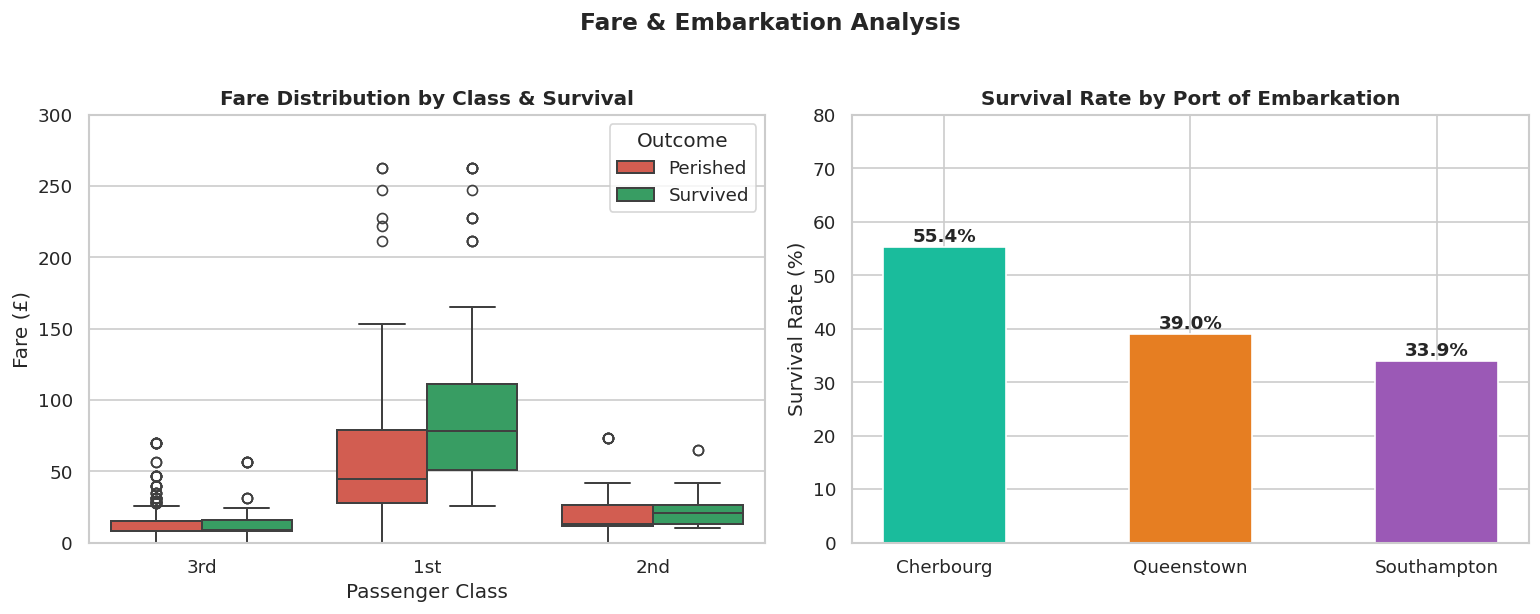

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot: Fare by class
ax = axes[0]
df_clean['PclassLabel'] = df_clean['Pclass'].map({1:'1st', 2:'2nd', 3:'3rd'})
sns.boxplot(data=df_clean, x='PclassLabel', y='Fare', hue='Survived',
            palette={0:'#E74C3C', 1:'#27AE60'}, ax=ax, linewidth=1.2)
ax.set_title('Fare Distribution by Class & Survival', fontsize=12, fontweight='bold')
ax.set_xlabel('Passenger Class'); ax.set_ylabel('Fare (£)')
ax.set_ylim(0, 300)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Perished', 'Survived'], title='Outcome')

# Bar: Survival by Embarkation port
ax = axes[1]
emb_map = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
df_clean['EmbarkLabel'] = df_clean['Embarked'].map(emb_map)
emb_rate = df_clean.groupby('EmbarkLabel')['Survived'].mean().reset_index()
emb_colors = ['#1ABC9C', '#E67E22', '#9B59B6']
bars = ax.bar(emb_rate['EmbarkLabel'], emb_rate['Survived']*100,
              color=emb_colors, edgecolor='white', width=0.5)
ax.set_title('Survival Rate by Port of Embarkation', fontsize=12, fontweight='bold')
ax.set_ylabel('Survival Rate (%)'); ax.set_ylim(0, 80)
for bar, r in zip(bars, emb_rate['Survived']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{r:.1%}', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('Fare & Embarkation Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fare_embarkation.png', bbox_inches='tight')
plt.show()

## 👨‍👩‍👧 Step 10 — Family Size Analysis

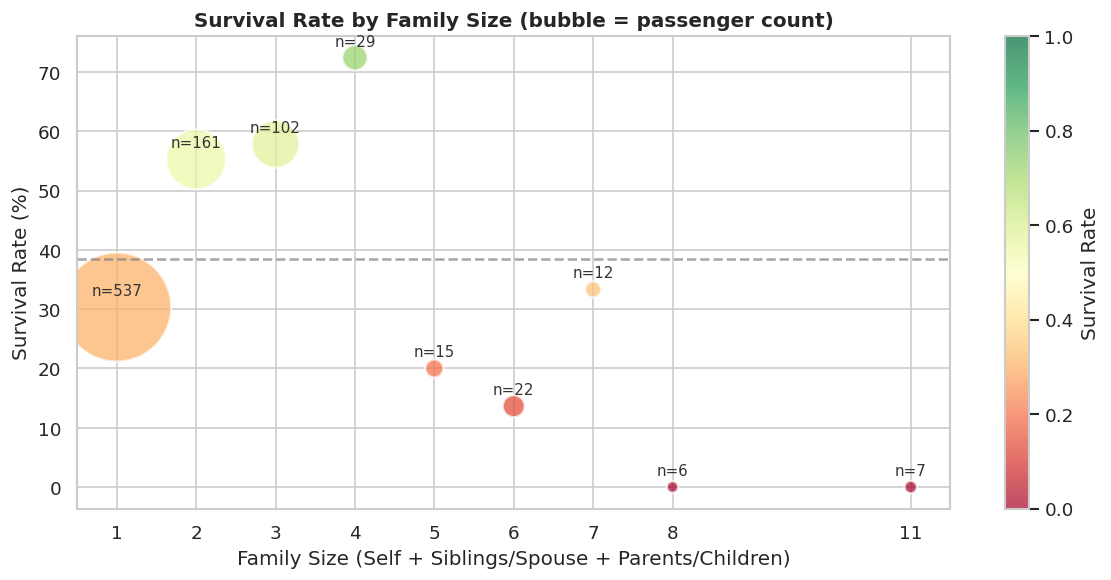


🔑 Solo travelers and very large families (7+) had below-average survival.


In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
fam_surv = df_clean.groupby('FamilySize')['Survived'].agg(['mean','count']).reset_index()
fam_surv.columns = ['FamilySize', 'SurvivalRate', 'Count']

# Bubble chart
scatter = ax.scatter(fam_surv['FamilySize'], fam_surv['SurvivalRate']*100,
                     s=fam_surv['Count']*8, alpha=0.7,
                     c=fam_surv['SurvivalRate'], cmap='RdYlGn',
                     vmin=0, vmax=1, edgecolors='white', linewidth=1.5)

for _, row in fam_surv.iterrows():
    ax.annotate(f"n={int(row['Count'])}",
                (row['FamilySize'], row['SurvivalRate']*100 + 2),
                ha='center', fontsize=9, color='#333')

plt.colorbar(scatter, ax=ax, label='Survival Rate')
ax.set_title('Survival Rate by Family Size (bubble = passenger count)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Family Size (Self + Siblings/Spouse + Parents/Children)')
ax.set_ylabel('Survival Rate (%)')
ax.set_xticks(fam_surv['FamilySize'])
ax.axhline(rate*100, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('family_size.png', bbox_inches='tight')
plt.show()
print('\n🔑 Solo travelers and very large families (7+) had below-average survival.')

## 🔗 Step 11 — Correlation Heatmap

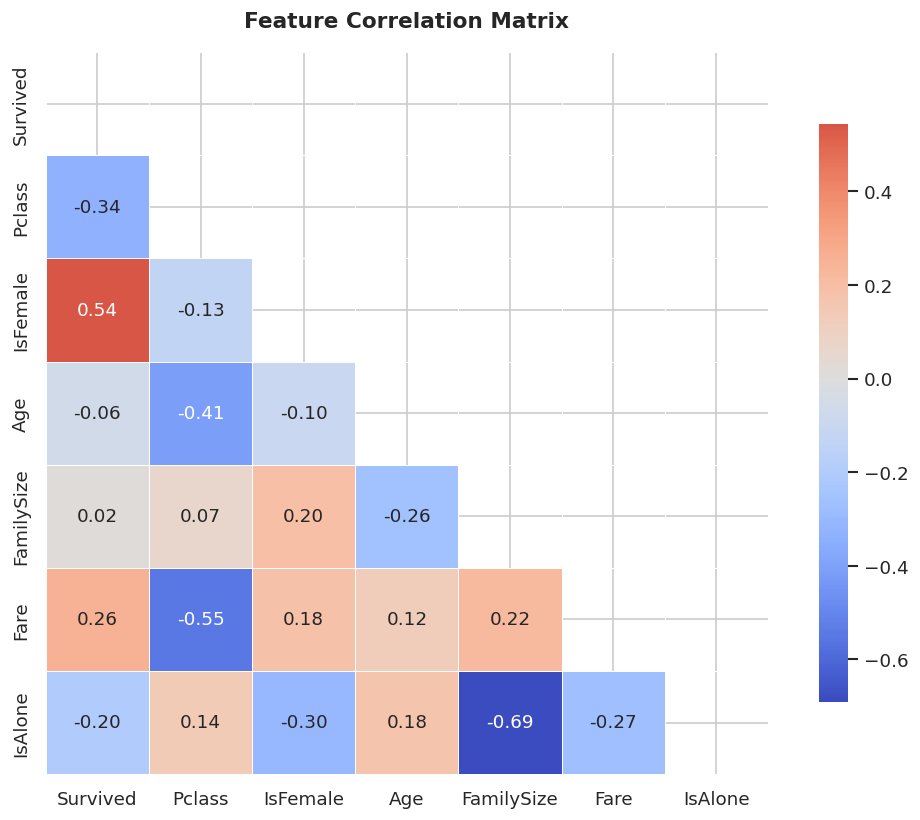


🔑 Strongest predictors of survival: Sex (IsFemale: +0.54), Pclass (-0.34), Fare (+0.26)


In [18]:
df_corr = df_clean.copy()
df_corr['IsFemale'] = (df_corr['Sex'] == 'female').astype(int)
numeric_cols = ['Survived', 'Pclass', 'IsFemale', 'Age', 'FamilySize', 'Fare', 'IsAlone']
corr_matrix = df_corr[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            ax=ax, center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 11})
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('\n🔑 Strongest predictors of survival: Sex (IsFemale: +0.54), Pclass (-0.34), Fare (+0.26)')

## 📝 Step 12 — Key Insight Report

In [20]:
report = """
╔══════════════════════════════════════════════════════════════════╗
║           🚢 TITANIC EDA — KEY INSIGHT REPORT                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Dataset : 891 passengers | 12 features | Training split         ║
║  Overall Survival Rate : 38.4% (342 survived, 549 perished)      ║
║                                                                  ║
║  INSIGHT 1 — GENDER WAS THE STRONGEST PREDICTOR                  ║
║  • Females: 74.2% survival vs Males: 18.9%                       ║
║  • "Women & children first" policy had a measurable impact       ║
║                                                                  ║
║  INSIGHT 2 — CLASS DETERMINED LIFE CHANCES                       ║
║  • 1st class: 63% | 2nd class: 47% | 3rd class: 24%              ║
║  • 1st class females nearly all survived (96.8%)                 ║
║  • 3rd class males had the worst outcome (13.5%)                 ║
║                                                                  ║
║  INSIGHT 3 — CHILDREN HAD PRIORITY                               ║
║  • Children (0-12): 58% survival — highest among all groups      ║
║  • Seniors (60+): 22.7% — lowest survival across age bands       ║
║                                                                  ║
║  INSIGHT 4 — FARE CORRELATES WITH SURVIVAL                       ║
║  • Higher fares → better deck position → easier evacuation       ║
║  • Cherbourg passengers (often 1st class) had 55.4% survival     ║
║                                                                  ║
║  INSIGHT 5 — FAMILY SIZE HAD A SWEET SPOT                        ║
║  • Family size 2-4: ~57% survival (helped evacuate together)     ║
║  • Alone (1): 30.4% | Very large families (7+): < 20%            ║
║                                                                  ║
║  DATA QUALITY NOTES                                              ║
║  • Cabin missing for 77% — not usable without imputation         ║
║  • Age missing for 20% — imputed by class+sex group medians      ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(report)


╔══════════════════════════════════════════════════════════════════╗
║           🚢 TITANIC EDA — KEY INSIGHT REPORT                    ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Dataset : 891 passengers | 12 features | Training split         ║
║  Overall Survival Rate : 38.4% (342 survived, 549 perished)      ║
║                                                                  ║
║  INSIGHT 1 — GENDER WAS THE STRONGEST PREDICTOR                  ║
║  • Females: 74.2% survival vs Males: 18.9%                       ║
║  • "Women & children first" policy had a measurable impact       ║
║                                                                  ║
║  INSIGHT 2 — CLASS DETERMINED LIFE CHANCES                       ║
║  • 1st class: 63% | 2nd class: 47% | 3rd class: 24%              ║
║  • 1st class females nearly all survived (96.8%)                 ║
║  • 3rd class males had the worst

## 🏁 Step 13 — Export All Charts
All charts are already saved in the working directory as PNG files.

In [21]:
import os
charts = [f for f in os.listdir('.') if f.endswith('.png')]
print('Exported charts:')
for c in sorted(charts):
    print(f'  {c}')

# Optional: zip all charts for download in Colab
# import zipfile
# with zipfile.ZipFile('titanic_charts.zip', 'w') as z:
#     for c in charts:
#         z.write(c)
# from google.colab import files
# files.download('titanic_charts.zip')

print('\n End-to-End Titanic EDA Complete!')

Exported charts:
  correlation_heatmap.png
  family_size.png
  fare_embarkation.png
  missing_values.png
  survival_by_age.png
  survival_by_class.png
  survival_by_sex.png
  survival_overall.png

 End-to-End Titanic EDA Complete!
